**Installing dependencies**

In [1]:
!pip install patool

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.5/86.5 kB 2.6 MB/s eta 0:00:00


In [2]:
!pip install krippendorff

In [3]:
!pip install tensorflow

In [4]:
import os
import random
import shutil
import krippendorff
import numpy as np
from tqdm import tqdm
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau

import torchvision.models as models
from torchvision import transforms

from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    f1_score,
    cohen_kappa_score,
    accuracy_score,
    roc_auc_score,
    precision_recall_curve,
    auc
)
from sklearn.preprocessing import label_binarize

from scipy.stats import pearsonr
import krippendorff
import patoolib

import tensorflow as tf


2025-09-27 11:36:49.983767: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1758973010.383301      36 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1758973010.500490      36 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


**Unzipping dataset**

https://mdiqbalbajmi00786.medium.com/how-to-unzip-a-zip-file-in-jupyter-google-colab-e024c5707e68

**Loading and Examining dataset**

In [5]:
root = "/kaggle/input/dl-a1-dataset/Dataset/Dataset"
img_dir = os.path.join(root, "images")
ann_dir = os.path.join(root, "annotations")

Expression: 0
Valence: -0.176846
Arousal: -0.0776398
Landmarks Before Re-shape: (136,)
Landmarks shape after reshape: (68, 2)


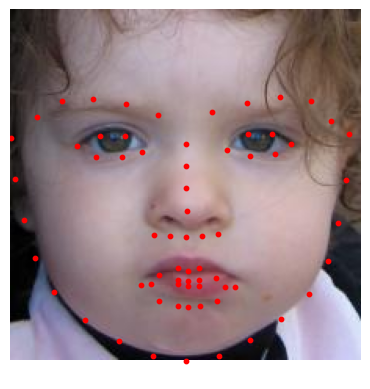

In [6]:
idx = 0
img_path = os.path.join(img_dir, f"{idx}.jpg")

img = Image.open(img_path)

# npy files
aro = np.load(os.path.join(ann_dir, f"{idx}_aro.npy"))
val = np.load(os.path.join(ann_dir, f"{idx}_val.npy"))
exp = np.load(os.path.join(ann_dir, f"{idx}_exp.npy"))
lnd = np.load(os.path.join(ann_dir, f"{idx}_lnd.npy"))

print("Expression:", exp)       # label
print("Valence:", val)
print("Arousal:", aro)
print("Landmarks Before Re-shape:", lnd.shape)
lnd = lnd.reshape(-1, 2)

print("Landmarks shape after reshape:", lnd.shape)

plt.imshow(img)
plt.scatter(lnd[:,0], lnd[:,1], c="r", s=10)
plt.axis("off")
plt.show()


Expression: 4
Valence: -0.142857
Arousal: 0.84127
Landmarks Before Re-shape: (136,)
Landmarks shape after reshape: (68, 2)


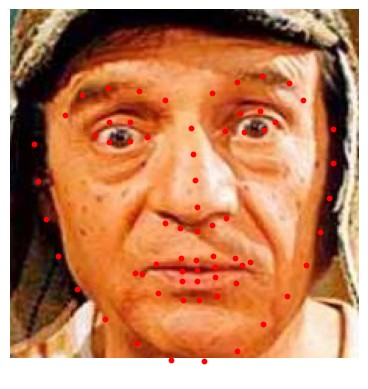

In [7]:
idx = 565
img_path = os.path.join(img_dir, f"{idx}.jpg")

img = Image.open(img_path)

# npy files
aro = np.load(os.path.join(ann_dir, f"{idx}_aro.npy"))
val = np.load(os.path.join(ann_dir, f"{idx}_val.npy"))
exp = np.load(os.path.join(ann_dir, f"{idx}_exp.npy"))
lnd = np.load(os.path.join(ann_dir, f"{idx}_lnd.npy"))

print("Expression:", exp)       # label
print("Valence:", val)
print("Arousal:", aro)
print("Landmarks Before Re-shape:", lnd.shape)
lnd = lnd.reshape(-1, 2)

print("Landmarks shape after reshape:", lnd.shape)

plt.imshow(img)
plt.scatter(lnd[:,0], lnd[:,1], c="r", s=10)
plt.axis("off")
plt.show()


**Splitting dataset for training & testing**

In [8]:

all_exp = []
img_ids = []

for fname in os.listdir(ann_dir):
    if fname.endswith("_exp.npy"):
        img_id = fname.replace("_exp.npy", "")
        img_ids.append(img_id)
        all_exp.append(np.load(os.path.join(ann_dir, fname), allow_pickle=True).item())

print(f"Found {len(img_ids)} valid IDs")
print("Sample IDs:", img_ids[:10])


Found 3999 valid IDs
Sample IDs: ['2820', '1757', '2691', '406', '2966', '4558', '1217', '1235', '2464', '2690']


In [9]:
ids_to_not_keep = []

for img_id in img_ids:
    exp = np.load(os.path.join(ann_dir, f"{img_id}_exp.npy"))
    val = np.load(os.path.join(ann_dir, f"{img_id}_val.npy"))
    aro = np.load(os.path.join(ann_dir, f"{img_id}_aro.npy"))

    if -2 in [exp, val, aro]:
        ids_to_not_keep.append(img_id)

print("Number of samples with -2:", len(ids_to_not_keep))
print("Examples of IDs with -2:", ids_to_not_keep[:20])

Number of samples with -2: 0
Examples of IDs with -2: []


In [10]:
for idx in ids_to_not_keep[:5]:
    img_path = os.path.join(img_dir, f"{idx}.jpg")
    img = Image.open(img_path)

    exp = np.load(os.path.join(ann_dir, f"{idx}_exp.npy"))
    val = np.load(os.path.join(ann_dir, f"{idx}_val.npy"))
    aro = np.load(os.path.join(ann_dir, f"{idx}_aro.npy"))
    lnd = np.load(os.path.join(ann_dir, f"{idx}_lnd.npy")).reshape(-1, 2)

    print(f"ID: {idx} | Expression: {exp} | Valence: {val} | Arousal: {aro}")

    plt.imshow(img)
    plt.scatter(lnd[:,0], lnd[:,1], c="r", s=10)
    plt.axis("off")
    plt.show()


In [11]:
ids_to_keep = [img_ids[i] for i in range(len(img_ids)) if i not in ids_to_not_keep]


In [12]:


all_exp = [int(np.load(os.path.join(ann_dir, f"{i}_exp.npy")))
           for i in map(int, ids_to_keep)]

train_ids, temp_ids, train_exp, temp_exp = train_test_split(
    ids_to_keep, all_exp,
    test_size=0.3,
    random_state=42,
    stratify=all_exp
)

val_ids, test_ids, val_exp, test_exp = train_test_split(
    temp_ids, temp_exp,
    test_size=0.5,
    random_state=42,
    stratify=temp_exp
)


In [13]:

print("Train size:", len(train_ids))
print("Val size:", len(val_ids))
print("Test size:", len(test_ids))


Train size: 2799
Val size: 600
Test size: 600


Now, we have image ids that will go in test and train respectively.

In [14]:
idx = train_ids[-1]
img_path = os.path.join(img_dir, f"{idx}.jpg")
aro = np.load(os.path.join(ann_dir, f"{idx}_aro.npy"))
val = np.load(os.path.join(ann_dir, f"{idx}_val.npy"))
exp = np.load(os.path.join(ann_dir, f"{idx}_exp.npy"))
lnd = np.load(os.path.join(ann_dir, f"{idx}_lnd.npy")).reshape(-1, 2)


**Data Augmentation**

In [15]:
train_aug = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2,
                           saturation=0.2, hue=0.1),
    transforms.RandomAdjustSharpness(sharpness_factor=2, p=0.3),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.2)
])

valid_aug = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])



In [16]:

class EmotionDataset(Dataset):
    def __init__(self, id_list, image_dir, anno_dir, transform=None):
        self.id_list = list(map(int, id_list))
        self.image_dir = image_dir
        self.anno_dir = anno_dir
        self.transform = transform

    def __len__(self):
        return len(self.id_list)

    def __getitem__(self, idx):
        img_id = self.id_list[idx]


        img_path = os.path.join(self.image_dir, f"{img_id}.jpg")
        img = Image.open(img_path).convert("RGB")
        if self.transform:
            img = self.transform(img)

        exp = int(np.load(os.path.join(self.anno_dir, f"{img_id}_exp.npy")))
        val = float(np.load(os.path.join(self.anno_dir, f"{img_id}_val.npy")))
        aro = float(np.load(os.path.join(self.anno_dir, f"{img_id}_aro.npy")))

        return (
            img,
            torch.tensor(exp, dtype=torch.long),     # CE loss
            torch.tensor(val, dtype=torch.float32),  # MSE loss
            torch.tensor(aro, dtype=torch.float32)   # MSE loss
        )

In [17]:

train_set = EmotionDataset(train_ids, img_dir, ann_dir, transform=train_aug)
valid_set = EmotionDataset(val_ids, img_dir, ann_dir, transform=valid_aug)
test_set = EmotionDataset(test_ids, img_dir, ann_dir, transform=valid_aug)

# DataLoaders
train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_set, batch_size=32, shuffle=False)
test_loader = DataLoader(test_set, batch_size=32, shuffle=False)

print("Training samples:", len(train_set))
print("Validation samples:", len(valid_set))


Training samples: 2799
Validation samples: 600


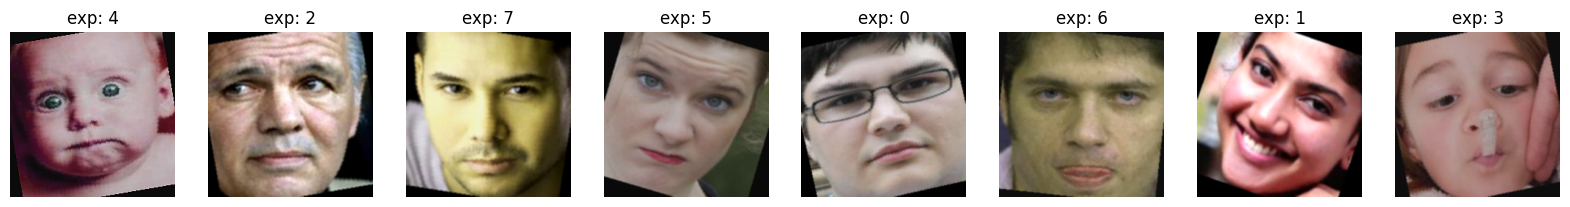

In [18]:
import matplotlib.pyplot as plt

images, exps, vals, aros = next(iter(train_loader))

fig, axes = plt.subplots(1, 8, figsize=(20, 5))
for i in range(8):
    img = images[i].permute(1, 2, 0).numpy()
    axes[i].imshow(img)
    axes[i].set_title(f"exp: {exps[i].item()}")
    axes[i].axis("off")

plt.show()


In [19]:
# test
img, exp, val, aro = train_set[0]
print("Image shape:", img.shape, "Expression:", exp, "Valence:", val, "Arousal:", aro)

Image shape: torch.Size([3, 224, 224]) Expression: tensor(4) Valence: tensor(-0.2092) Arousal: tensor(0.8667)


**Model Training**

*Efficient net*

In [20]:
IMG_SHAPE = (224, 224, 3)
model0 = tf.keras.applications.EfficientNetB0(input_shape=IMG_SHAPE, include_top=False, weights="imagenet")
tf.keras.utils.plot_model(model0)
model0.summary()

I0000 00:00:1758973113.571576      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1758973113.572538      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "efficientnetb0"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,049,571 (15.45 MB)

 Trainable params: 4,007,548 (15.29 MB)

 Non-trainable params: 42,023 (164.16 KB)

In [21]:


class MultiHead(nn.Module):
    def __init__(self, in_features, num_classes=8):
        super().__init__()
        self.expression = nn.Linear(in_features, num_classes)  # classification
        self.valence = nn.Linear(in_features, 1)               # regression
        self.arousal = nn.Linear(in_features, 1)               # regression

    def forward(self, x):
        exp = self.expression(x)
        val = self.valence(x)
        aro = self.arousal(x)
        return exp, val, aro



In [22]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)

in_features = model.classifier[1].in_features

model.classifier = MultiHead(in_features, num_classes=8)


model = model.to(device)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth
100%|██████████| 20.5M/20.5M [00:00<00:00, 127MB/s] 


In [23]:
model = model.to(device)
print(model)

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

**Loss function**

In [24]:


criterion_ce = nn.CrossEntropyLoss()
criterion_mse = nn.MSELoss()

optimizer = optim.Adam(model.parameters(), lr=1e-4)

**Training**

In [25]:

best_val_loss = float("inf")
patience = 7
counter = 0
checkpoint_path = "best_model.pth"

In [26]:
!pip install krippendorff


In [27]:

class TrainerForEfficientNet:
    def __init__(
        self,
        model,
        train_loader,
        valid_loader,
        device,
        num_epochs=60,
        patience=10,
        reg_weight_val=0.5,
        reg_weight_aro=0.5,
    ):
        self.model = model
        self.train_loader = train_loader
        self.valid_loader = valid_loader
        self.optimizer = optimizer
        self.criterion_ce = criterion_ce
        self.criterion_mse = criterion_mse
        self.device = device
        self.num_epochs = num_epochs
        self.patience = patience
        self.reg_w_val = reg_weight_val
        self.reg_w_aro = reg_weight_aro

        self.scheduler = ReduceLROnPlateau(self.optimizer, mode="min", factor=0.5, patience=3)

        self.history = {
            "train_loss": [],
            "train_acc": [],
            "val_loss": [],
            "val_acc": [],
            "rmse": [],
            "corr": [],
            "ccc": [],
            "sagr": [],
            "f1": [],
            "kappa": [],
            "kripp_alpha": [],
            "roc_auc": [],
            "pr_auc": [],
            "train_ce": [],
            "train_mse_val": [],
            "train_mse_aro": [],
            "val_ce": [],
            "val_mse_val": [],
            "val_mse_aro": [],
        }

    def get_features(self, images):
        if hasattr(self.model, "features"):
            feats = self.model.features(images)
            pooled = torch.flatten(self.model.avgpool(feats), 1)
            return pooled
        elif hasattr(self.model, "layer4"):
            x = self.model.conv1(images)
            x = self.model.bn1(x)
            x = self.model.relu(x)
            x = self.model.maxpool(x)
            x = self.model.layer1(x)
            x = self.model.layer2(x)
            x = self.model.layer3(x)
            x = self.model.layer4(x)
            pooled = torch.flatten(self.model.avgpool(x), 1)
            return pooled
        elif hasattr(self.model, "backbone"):
            feats = self.model.backbone(images)
            return feats
        else:
            raise AttributeError("Unsupported model architecture")

    def forward_heads(self, pooled):
        if hasattr(self.model, "classifier"):
            exp_out, val_out, aro_out = self.model.classifier(pooled)
        elif hasattr(self.model, "heads"):
            exp_out, val_out, aro_out = self.model.heads(pooled)
        else:
            raise AttributeError("Model has no recognized heads/classifier")
        return exp_out, val_out.squeeze(-1), aro_out.squeeze(-1)

    def safe_krippendorff(self, gold, pred):
        try:
            return krippendorff.alpha(reliability_data=np.vstack([gold, pred]))
        except Exception:
            return float("nan")

    def fit(self):
        best_val_loss = np.inf
        patience_counter = 0

        self.model.to(self.device)

        for epoch in range(self.num_epochs):
            # Training
            self.model.train()
            train_loss_sum = 0.0
            train_ce_sum = 0.0
            train_mse_val_sum = 0.0
            train_mse_aro_sum = 0.0
            train_correct = 0
            train_total = 0

            for images, exp, val, aro in tqdm(self.train_loader, desc=f"Epoch {epoch+1}/{self.num_epochs} [Train]"):
                images = images.to(self.device)
                exp = exp.to(self.device).long()
                val = val.to(self.device).float()
                aro = aro.to(self.device).float()

                self.optimizer.zero_grad()
                pooled = self.get_features(images)
                exp_out, val_out, aro_out = self.forward_heads(pooled)

                ce = self.criterion_ce(exp_out, exp)
                mse_val = self.criterion_mse(val_out, val)
                mse_aro = self.criterion_mse(aro_out, aro)

                loss = ce + self.reg_w_val * mse_val + self.reg_w_aro * mse_aro
                loss.backward()
                self.optimizer.step()

                batch_size = images.size(0)
                train_loss_sum += loss.item() * batch_size
                train_ce_sum += ce.item() * batch_size
                train_mse_val_sum += mse_val.item() * batch_size
                train_mse_aro_sum += mse_aro.item() * batch_size

                _, preds = torch.max(exp_out, 1)
                train_correct += (preds == exp).sum().item()
                train_total += batch_size

            train_loss = train_loss_sum / max(1, len(self.train_loader.dataset))
            train_acc = train_correct / max(1, train_total)
            train_ce_avg = train_ce_sum / max(1, len(self.train_loader.dataset))
            train_mse_val_avg = train_mse_val_sum / max(1, len(self.train_loader.dataset))
            train_mse_aro_avg = train_mse_aro_sum / max(1, len(self.train_loader.dataset))

            # Validation
            self.model.eval()
            val_loss_sum = 0.0
            val_ce_sum = 0.0
            val_mse_val_sum = 0.0
            val_mse_aro_sum = 0.0
            val_correct = 0
            val_total = 0

            all_preds_reg = []
            all_labels_reg = []
            all_exp_preds = []
            all_exp_labels = []
            all_probs = []

            with torch.no_grad():
                for images, exp, val, aro in tqdm(self.valid_loader, desc=f"Epoch {epoch+1}/{self.num_epochs} [Val]"):
                    images = images.to(self.device)
                    exp = exp.to(self.device).long()
                    val = val.to(self.device).float()
                    aro = aro.to(self.device).float()

                    pooled = self.get_features(images)
                    exp_out, val_out, aro_out = self.forward_heads(pooled)

                    ce = self.criterion_ce(exp_out, exp)
                    mse_val = self.criterion_mse(val_out, val)
                    mse_aro = self.criterion_mse(aro_out, aro)

                    loss = ce + self.reg_w_val * mse_val + self.reg_w_aro * mse_aro
                    batch_size = images.size(0)
                    val_loss_sum += loss.item() * batch_size
                    val_ce_sum += ce.item() * batch_size
                    val_mse_val_sum += mse_val.item() * batch_size
                    val_mse_aro_sum += mse_aro.item() * batch_size

                    _, preds = torch.max(exp_out, 1)
                    val_correct += (preds == exp).sum().item()
                    val_total += batch_size

                    # regression outputs & labels
                    all_preds_reg.append(torch.stack([val_out, aro_out], dim=1).cpu())
                    all_labels_reg.append(torch.stack([val, aro], dim=1).cpu())

                    # classification preds/labels/probs
                    all_exp_preds.append(preds.cpu())
                    all_exp_labels.append(exp.cpu())
                    all_probs.append(torch.softmax(exp_out, dim=1).cpu())

            val_loss = val_loss_sum / max(1, len(self.valid_loader.dataset))
            val_acc = val_correct / max(1, val_total)
            val_ce_avg = val_ce_sum / max(1, len(self.valid_loader.dataset))
            val_mse_val_avg = val_mse_val_sum / max(1, len(self.valid_loader.dataset))
            val_mse_aro_avg = val_mse_aro_sum / max(1, len(self.valid_loader.dataset))


            try:
                all_preds_reg = torch.cat(all_preds_reg).numpy()
                all_labels_reg = torch.cat(all_labels_reg).numpy()
            except Exception:
                all_preds_reg = np.zeros((0, 2))
                all_labels_reg = np.zeros((0, 2))

            rmse = np.sqrt(np.mean((all_preds_reg - all_labels_reg) ** 2)) if all_preds_reg.size else float("nan")


            if all_preds_reg.size and np.std(all_preds_reg.flatten()) > 1e-8 and np.std(all_labels_reg.flatten()) > 1e-8:
                corr = np.corrcoef(all_preds_reg.flatten(), all_labels_reg.flatten())[0, 1]
            else:
                corr = 0.0

            denom = (np.var(all_preds_reg.flatten()) + np.var(all_labels_reg.flatten()) +
                     (np.mean(all_preds_reg.flatten()) - np.mean(all_labels_reg.flatten())) ** 2) if all_preds_reg.size else 0.0
            if all_preds_reg.size and denom > 1e-8:
                ccc = (2 * np.cov(all_preds_reg.flatten(), all_labels_reg.flatten())[0, 1]) / denom
            else:
                ccc = 0.0

            sagr = (np.mean(np.sign(all_preds_reg) == np.sign(all_labels_reg))) if all_preds_reg.size else float("nan")

            # classification metrics
            all_exp_preds = np.concatenate([x.numpy() for x in all_exp_preds]) if len(all_exp_preds) else np.array([])
            all_exp_labels = np.concatenate([x.numpy() for x in all_exp_labels]) if len(all_exp_labels) else np.array([])

            if all_exp_labels.size:
                f1 = f1_score(all_exp_labels, all_exp_preds, average="weighted", zero_division=0)
                kappa = cohen_kappa_score(all_exp_labels, all_exp_preds)
                kripp_alpha = self.safe_krippendorff(all_exp_labels, all_exp_preds)
            else:
                f1 = float("nan")
                kappa = float("nan")
                kripp_alpha = float("nan")

            if len(all_probs):
                all_probs = torch.cat(all_probs, dim=0).numpy()
            else:
                all_probs = np.zeros((0, 0))

            roc_auc = float("nan")
            pr_auc = float("nan")

            if all_exp_labels.size and all_probs.size:
                n_classes = all_probs.shape[1]
                if len(np.unique(all_exp_labels)) > 1:
                    try:
                        all_exp_onehot = label_binarize(all_exp_labels, classes=np.arange(n_classes))
                        if all_exp_onehot.shape[1] == all_probs.shape[1]:
                            roc_auc = roc_auc_score(all_exp_onehot, all_probs, multi_class="ovr", average="macro")
                            # PR-AUC: compute per-class PR AUC then macro-average; guard degenerate classes
                            pr_list = []
                            for i in range(n_classes):
                                try:
                                    precision, recall, _ = precision_recall_curve(all_exp_onehot[:, i], all_probs[:, i])
                                    pr_list.append(auc(recall, precision))
                                except Exception:

                                    pass
                            if pr_list:
                                pr_auc = float(np.mean(pr_list))
                            else:
                                pr_auc = float("nan")
                    except Exception:
                        roc_auc = float("nan")
                        pr_auc = float("nan")


            try:
                self.scheduler.step(val_loss)
            except Exception:
                pass

            # save history
            self.history["train_loss"].append(train_loss)
            self.history["train_acc"].append(train_acc)
            self.history["val_loss"].append(val_loss)
            self.history["val_acc"].append(val_acc)
            self.history["rmse"].append(rmse)
            self.history["corr"].append(corr)
            self.history["ccc"].append(ccc)
            self.history["sagr"].append(sagr)
            self.history["f1"].append(f1)
            self.history["kappa"].append(kappa)
            self.history["kripp_alpha"].append(kripp_alpha)
            self.history["roc_auc"].append(roc_auc)
            self.history["pr_auc"].append(pr_auc)
            self.history["train_ce"].append(train_ce_avg)
            self.history["train_mse_val"].append(train_mse_val_avg)
            self.history["train_mse_aro"].append(train_mse_aro_avg)
            self.history["val_ce"].append(val_ce_avg)
            self.history["val_mse_val"].append(val_mse_val_avg)
            self.history["val_mse_aro"].append(val_mse_aro_avg)

            print(
                f"Epoch {epoch+1}: Train Acc {train_acc:.4f}, Val Acc {val_acc:.4f}, "
                f"F1 {np.nan_to_num(f1):.4f}, Kappa {np.nan_to_num(kappa):.4f}, Alpha {np.nan_to_num(kripp_alpha):.4f}, "
                f"ROC-AUC {np.nan_to_num(roc_auc):.4f}, PR-AUC {np.nan_to_num(pr_auc):.4f}, "
                f"Train CE {train_ce_avg:.4f}, Val CE {val_ce_avg:.4f}"
            )

            # early stopping
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= self.patience:
                    print(f"Early stopping at epoch {epoch+1}")
                    break

        return self.history


In [28]:
print("Train set size:", len(train_set))
print("Valid set size:", len(valid_set))
print("Test set size:", len(test_set))

for i, batch in enumerate(train_loader):
    if i == 0:
        print("Batch size:", batch[0].shape)
        break
    pass

print("Batches per epoch:", len(train_loader))


Train set size: 2799
Valid set size: 600
Test set size: 600
Batch size: torch.Size([32, 3, 224, 224])
Batches per epoch: 88


In [29]:
trainer = TrainerForEfficientNet(model, train_loader, valid_loader, num_epochs=60, patience=10, device=device)
history = trainer.fit()




Epoch 1/60 [Val]: 100%|██████████| 19/19 [00:08<00:00,  2.37it/s]


Epoch 1: Train Acc 0.1840, Val Acc 0.2617, F1 0.2265, Kappa 0.1562, Alpha 0.0851, ROC-AUC 0.6833, PR-AUC 0.2476, Train CE 2.0445, Val CE 1.9659


Epoch 2/60 [Val]: 100%|██████████| 19/19 [00:04<00:00,  3.92it/s]


Epoch 2: Train Acc 0.2997, Val Acc 0.3250, F1 0.2963, Kappa 0.2286, Alpha 0.1155, ROC-AUC 0.7666, PR-AUC 0.3395, Train CE 1.8659, Val CE 1.7543


Epoch 3/60 [Val]: 100%|██████████| 19/19 [00:04<00:00,  3.81it/s]


...

Epoch 16: Train Acc 0.7706, Val Acc 0.4783, F1 0.4775, Kappa 0.4038, Alpha 0.3458, ROC-AUC 0.8390, PR-AUC 0.4911, Train CE 0.6536, Val CE 1.6434


Epoch 17/60 [Val]: 100%|██████████| 19/19 [00:04<00:00,  4.11it/s]


Epoch 17: Train Acc 0.7992, Val Acc 0.4700, F1 0.4663, Kappa 0.3943, Alpha 0.3247, ROC-AUC 0.8360, PR-AUC 0.4804, Train CE 0.5964, Val CE 1.6942


Epoch 18/60 [Val]: 100%|██████████| 19/19 [00:04<00:00,  4.15it/s]


Epoch 18: Train Acc 0.8035, Val Acc 0.4700, F1 0.4637, Kappa 0.3943, Alpha 0.3262, ROC-AUC 0.8352, PR-AUC 0.4758, Train CE 0.5674, Val CE 1.7097
Early stopping at epoch 18


In [30]:
history1 = history

In [31]:
import pandas as pd

In [32]:
df = pd.DataFrame(history)


In [33]:
import matplotlib.pyplot as plt


**Classification metrics**

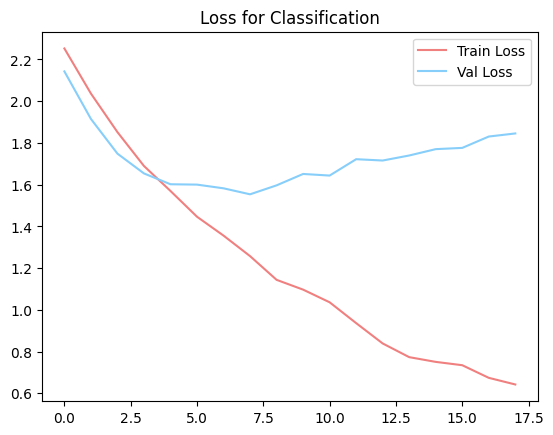

In [34]:
plt.figure()
plt.plot(df["train_loss"], label="Train Loss", color="lightcoral")
plt.plot(df["val_loss"], label="Val Loss", color="lightskyblue")
plt.legend()
plt.title("Loss for Classification")
plt.show()


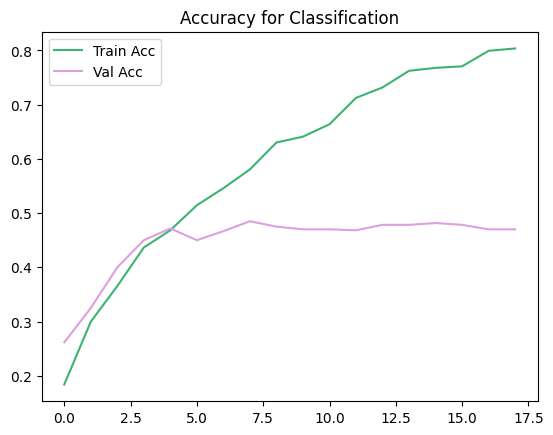

In [35]:
plt.figure()
plt.plot(df["train_acc"], label="Train Acc", color="mediumseagreen")
plt.plot(df["val_acc"], label="Val Acc", color="plum")
plt.legend()
plt.title("Accuracy for Classification")
plt.show()

In [36]:
class_df = df[[
    "train_loss", "val_loss",
    "train_acc", "val_acc",
    "f1", "kappa", "kripp_alpha", "roc_auc", "pr_auc"
]]


In [37]:
class_df

,train_loss,val_loss,train_acc,val_acc,f1,kappa,kripp_alpha,roc_auc,pr_auc
0,2.252339,2.142477,0.183994,0.261667,0.226451,0.156190,0.085128,0.683292,0.247629
1,2.036424,1.914815,0.299750,0.325000,0.296329,0.228571,0.115527,0.766644,0.339489
2,1.851534,1.748476,0.365488,0.400000,0.390519,0.314286,0.271065,0.807429,0.416479
3,1.689279,1.653642,0.436584,0.450000,0.442661,0.371429,0.297007,0.824911,0.456127
4,1.569617,1.601729,0.468382,0.471667,0.461786,0.396190,0.349834,0.838759,0.479581
5,1.446106,1.600033,0.514469,0.450000,0.443424,0.371429,0.341758,0.838705,0.473815
6,1.355681,1.582310,0.545909,0.466667,0.461559,0.390476,0.336620,0.843286,0.484994
7,1.257364,1.553583,0.580564,0.485000,0.479310,0.411429,0.330510,0.851403,0.496054
8,1.143786,1.596477,0.630225,0.475000,0.472114,0.400000,0.347625,0.848387,0.495062
9,1.096837,1.651094,0.640943,0.470000,0.464534,0.394286,0.345583,0.843149,0.482774


**Regression metrics**

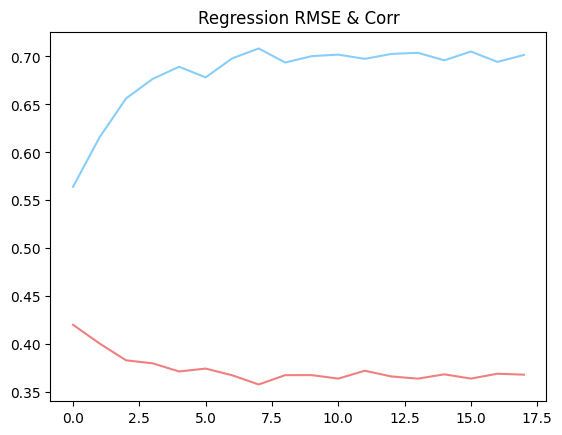

In [38]:

plt.figure()
plt.plot(df["rmse"], label="RMSE", color="lightcoral")
plt.plot(df["corr"], label="Corr", color="lightskyblue")
plt.title("Regression RMSE & Corr")
plt.show()



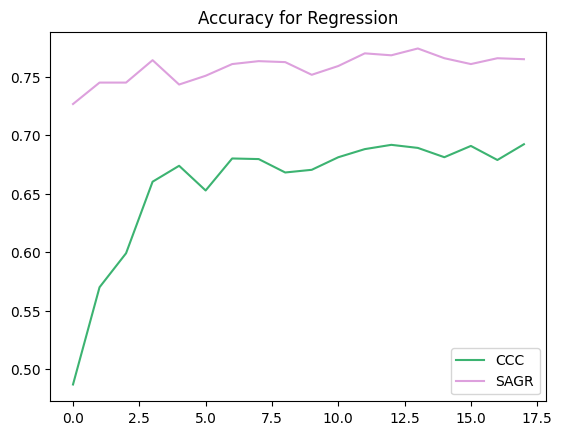

In [39]:
plt.plot(df["ccc"], label="CCC", color="mediumseagreen")
plt.plot(df["sagr"], label="SAGR", color="plum")
plt.legend()
plt.title("Accuracy for Regression")
plt.show()

In [40]:
regr_df = df[["rmse","corr","ccc","sagr"]]


In [41]:
regr_df

,rmse,corr,ccc,sagr
0,0.420159,0.564039,0.486821,0.726667
1,0.400650,0.615688,0.569969,0.745000
2,0.383088,0.656220,0.599056,0.745000
3,0.379963,0.676560,0.660226,0.764167
4,0.371429,0.689275,0.673847,0.743333
5,0.374475,0.678192,0.652728,0.750833
6,0.367485,0.698034,0.680102,0.760833
7,0.357883,0.708351,0.679582,0.763333
8,0.367611,0.693694,0.668115,0.762500
9,0.367641,0.700364,0.670405,0.751667


**Testing Model**

In [42]:
images_shown = 10


In [43]:
def test_model(model, images_shown=10):
    model.eval()
    correct_samples, incorrect_samples = [], []

    with torch.no_grad():
        for images, exp, val, aro in valid_loader:
            images, exp, val, aro = (
                images.to(device),
                exp.to(device).long(),
                val.to(device).float(),
                aro.to(device).float()
            )


            try:
                exp_out, val_out, aro_out = model(images)
            except TypeError:
                if hasattr(model, "features") and hasattr(model, "classifier"):
                    feats = model.features(images)
                    pooled = torch.flatten(model.avgpool(feats), 1)
                    exp_out = model.classifier["expression"](pooled)
                    val_out = model.classifier["valence"](pooled).squeeze(-1)
                    aro_out = model.classifier["arousal"](pooled).squeeze(-1)

                elif hasattr(model, "fc"):  # ResNet
                    feats = torch.flatten(model.avgpool(
                        model.layer4(model.layer3(model.layer2(
                            model.layer1(model.relu(model.bn1(model.conv1(images)))))))
                    ), 1)
                    exp_out = model.classifier["expression"](feats)
                    val_out = model.classifier["valence"](feats).squeeze(-1)
                    aro_out = model.classifier["arousal"](feats).squeeze(-1)

                elif hasattr(model, "backbone") and hasattr(model, "heads"):
                    feats = model.backbone(images)
                    exp_out = model.heads["expression"](feats)
                    val_out = model.heads["valence"](feats).squeeze(-1)
                    aro_out = model.heads["arousal"](feats).squeeze(-1)

                else:
                    raise ValueError("Unknown model architecture. Please adapt test_model.")

            # Predictions
            _, preds = torch.max(exp_out, 1)
            val_preds = val_out.cpu().numpy()
            aro_preds = aro_out.cpu().numpy()

            for i in range(len(exp)):
                sample = (
                    images[i].cpu(),
                    preds[i].item(), exp[i].item(),            # Expression pred & true
                    val_preds[i].item(), val[i].item(),        # Valence pred & true
                    aro_preds[i].item(), aro[i].item()         # Arousal pred & true
                )
                if preds[i] == exp[i]:
                    correct_samples.append(sample)
                else:
                    incorrect_samples.append(sample)

    return correct_samples, incorrect_samples

In [44]:
correct_samples,incorrect_samples = test_model(model)

In [45]:

correct_show = random.sample(correct_samples, min(images_shown, len(correct_samples)))
incorrect_show = random.sample(incorrect_samples, min(images_shown, len(incorrect_samples)))


In [46]:

def show_examples(samples, title):
    plt.figure(figsize=(12, 6))
    for i, (img, pred, label, val_pred, val_true, aro_pred, aro_true) in enumerate(samples):
        plt.subplot(2, 5, i+1)
        plt.imshow(img.permute(1, 2, 0))
        plt.title(
            f"Exp: {pred}/{label}\n"
            f"Val: {val_pred:.2f}/{val_true:.2f}\n"
            f"Aro: {aro_pred:.2f}/{aro_true:.2f}",
            fontsize=12
        )
        plt.axis("off")
    plt.suptitle(title, fontsize=14)
    plt.show()


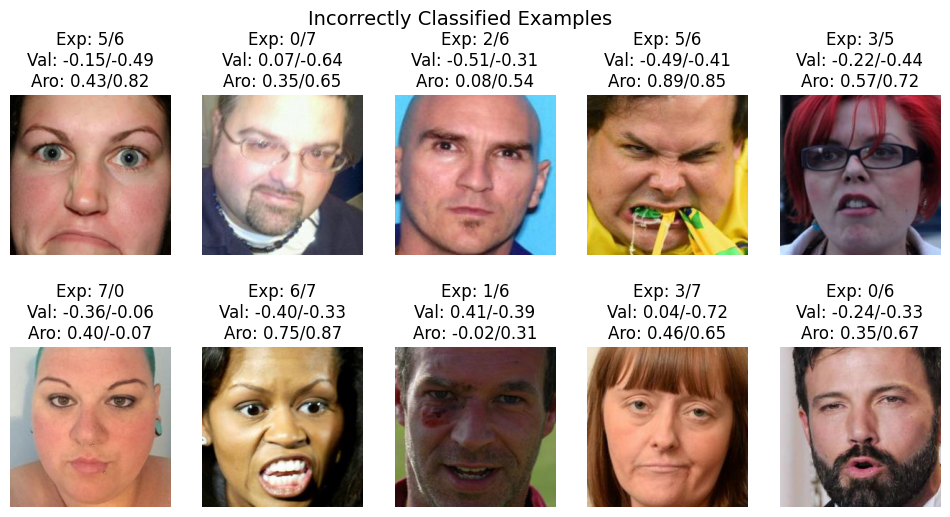

In [47]:
show_examples(incorrect_show, "Incorrectly Classified Examples")

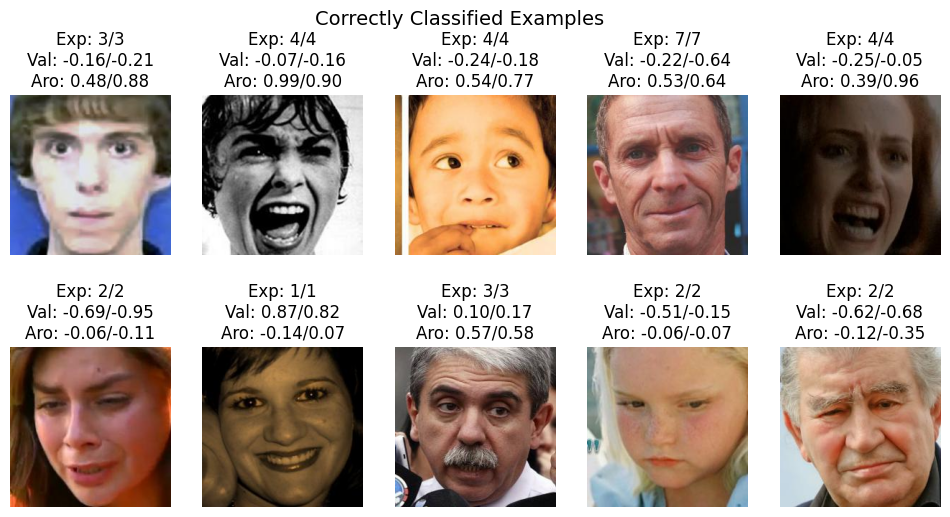

In [48]:
show_examples(correct_show, "Correctly Classified Examples")

*Resnet18*

In [49]:
from torchvision.models import resnet50
model = resnet50(weights="IMAGENET1K_V1")


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 171MB/s] 


In [50]:


class ResNet50MultiTask(nn.Module):
    def __init__(self, num_classes=8):
        super().__init__()
        self.backbone = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()  # remove original classifier

        self.heads = nn.ModuleDict({
            "expression": nn.Linear(in_features, num_classes),  # classification
            "valence": nn.Linear(in_features, 1),               # regression
            "arousal": nn.Linear(in_features, 1)                # regression
        })

    def forward(self, x):
        feats = self.backbone(x)
        exp = self.heads["expression"](feats)
        val = self.heads["valence"](feats)
        aro = self.heads["arousal"](feats)
        return exp, val, aro



**Transfer Learning**

In [51]:


class TrainerForResnet50:
    def __init__(self, model,
                 num_epochs=50, patience=10, device="cuda", clip_grad=1.0):

        self.model = model
        self.train_loader = train_loader
        self.valid_loader = valid_loader
        self.num_epochs = num_epochs
        self.patience = patience
        self.device = device
        self.clip_grad = clip_grad

        # Different LR for backbone vs heads
        self.optimizer = torch.optim.Adam([
            {"params": model.backbone.parameters(), "lr": 1e-4},
            {"params": model.heads.parameters(), "lr": 1e-3}
        ])

        self.criterion_ce = nn.CrossEntropyLoss()
        self.criterion_mse = nn.MSELoss()

        # LR scheduler
        self.scheduler = ReduceLROnPlateau(
            self.optimizer, mode="min", factor=0.5, patience=3
        )

        # Track metrics
        self.history = {k: [] for k in [
            "train_loss", "train_acc", "val_loss", "val_acc",
            "rmse", "corr", "ccc", "sagr",
            "f1", "kappa", "kripp_alpha", "roc_auc", "pr_auc"
        ]}


    def corr(self, a, b):
        a = np.asarray(a).flatten()
        b = np.asarray(b).flatten()
        if a.size == 0:
            return np.nan
        if np.allclose(a, a[0]) or np.allclose(b, b[0]):
            return np.nan
        return float(np.corrcoef(a, b)[0, 1])

    def ccc(self, a, b):
        a = np.asarray(a).flatten()
        b = np.asarray(b).flatten()
        if a.size == 0:
            return np.nan
        var_a = np.var(a)
        var_b = np.var(b)
        denom = var_a + var_b + (np.mean(a) - np.mean(b)) ** 2
        if denom == 0:
            return np.nan
        cov = np.cov(a, b)[0, 1]
        return 2.0 * cov / denom

    def _compute_roc_pr(self, all_exp_labels, all_exp_probs):
        all_exp_labels = np.asarray(all_exp_labels).astype(int).flatten()
        all_exp_probs = np.asarray(all_exp_probs).astype(float)
        n_samples = len(all_exp_labels)
        if n_samples == 0:
            return np.nan, np.nan

        n_classes = all_exp_probs.shape[1]
        per_class_roc = []
        per_class_pr = []

        for i in range(n_classes):
            y_true_i = (all_exp_labels == i).astype(int)
            pos = int(y_true_i.sum())
            if pos == 0:
                continue
            if pos == n_samples:
                continue

            scores = all_exp_probs[:, i]
            try:
                # binary roc for this class (one-vs-rest)
                r = roc_auc_score(y_true_i, scores)
                precision, recall, _ = precision_recall_curve(y_true_i, scores)
                pr = auc(recall, precision)
                per_class_roc.append(r)
                per_class_pr.append(pr)
            except Exception as e:
                continue

        roc_auc = float(np.mean(per_class_roc)) if len(per_class_roc) > 0 else np.nan
        pr_auc = float(np.mean(per_class_pr)) if len(per_class_pr) > 0 else np.nan
        return roc_auc, pr_auc

    def fit(self):
        self.model.to(self.device)
        best_val_loss = np.inf
        patience_counter = 0

        for epoch in range(self.num_epochs):
            #  Training
            self.model.train()
            train_loss, correct, total = 0.0, 0, 0

            for images, exp, val, aro in tqdm(
                self.train_loader,
                desc=f"Epoch {epoch+1}/{self.num_epochs} [Train]",
                leave=False
            ):
                images = images.to(self.device)
                exp = exp.to(self.device).long()
                val = val.to(self.device).float()
                aro = aro.to(self.device).float()

                self.optimizer.zero_grad()
                with torch.cuda.amp.autocast(dtype=torch.float16):
                    exp_out, val_out, aro_out = self.model(images)
                    val_out = val_out.squeeze(-1)
                    aro_out = aro_out.squeeze(-1)

                    loss = (
                        self.criterion_ce(exp_out, exp)
                        + self.criterion_mse(val_out, val)
                        + self.criterion_mse(aro_out, aro)
                    )

                loss.backward()
                torch.nn.utils.clip_grad_norm_(self.model.parameters(), self.clip_grad)
                self.optimizer.step()

                train_loss += float(loss.item()) * images.size(0)
                _, preds = torch.max(exp_out, 1)
                correct += (preds == exp).sum().item()
                total += exp.size(0)

            train_loss /= max(1, len(self.train_loader.dataset))
            train_acc = correct / max(1, total)

            #  Validation
            self.model.eval()
            val_loss, correct, total = 0.0, 0, 0
            all_preds, all_labels = [], []
            all_exp_preds, all_exp_labels = [], []
            all_exp_probs = []

            with torch.no_grad():
                for images, exp, val, aro in tqdm(
                    self.valid_loader,
                    desc=f"Epoch {epoch+1}/{self.num_epochs} [Val]",
                    leave=False
                ):
                    images = images.to(self.device)
                    exp = exp.to(self.device).long()
                    val = val.to(self.device).float()
                    aro = aro.to(self.device).float()

                    exp_out, val_out, aro_out = self.model(images)
                    val_out = val_out.squeeze(-1)
                    aro_out = aro_out.squeeze(-1)

                    loss = (
                        self.criterion_ce(exp_out, exp)
                        + self.criterion_mse(val_out, val)
                        + self.criterion_mse(aro_out, aro)
                    )

                    val_loss += float(loss.item()) * images.size(0)
                    _, preds = torch.max(exp_out, 1)
                    correct += (preds == exp).sum().item()
                    total += exp.size(0)

                    all_preds.append(
                        torch.cat([val_out.unsqueeze(1), aro_out.unsqueeze(1)], dim=1).cpu()
                    )
                    all_labels.append(
                        torch.cat([val.view(-1, 1), aro.view(-1, 1)], dim=1).cpu()
                    )
                    all_exp_preds.append(preds.cpu())
                    all_exp_labels.append(exp.cpu())
                    all_exp_probs.append(torch.softmax(exp_out, dim=1).cpu())

            if len(all_exp_labels) == 0:
                continue

            val_loss /= max(1, len(self.valid_loader.dataset))
            val_acc = correct / max(1, total)

            all_preds = torch.cat(all_preds).numpy()
            all_labels = torch.cat(all_labels).numpy()
            all_exp_preds = torch.cat(all_exp_preds).numpy()
            all_exp_labels = torch.cat(all_exp_labels).numpy()
            all_exp_probs = torch.cat(all_exp_probs).numpy()

            # Regression metrics
            rmse = np.sqrt(np.mean((all_preds - all_labels) ** 2))
            corr = self.corr(all_preds.flatten(), all_labels.flatten())
            ccc = self.ccc(all_preds.flatten(), all_labels.flatten())
            sagr = np.mean(np.sign(all_preds.flatten()) == np.sign(all_labels.flatten()))

            # Classification metrics
            try:
                f1 = f1_score(all_exp_labels, all_exp_preds, average="weighted")
            except Exception as e:
                f1 = np.nan
            try:
                kappa = cohen_kappa_score(all_exp_labels, all_exp_preds)
            except Exception as e:
                kappa = np.nan

            try:
                kripp_alpha = krippendorff.alpha(
                    reliability_data=np.vstack([all_exp_labels, all_exp_preds])
                )
            except Exception as e:
                kripp_alpha = np.nan

            # ROC / PR:
            roc_auc, pr_auc = self._compute_roc_pr(all_exp_labels, all_exp_probs)

            for k, v in zip(self.history.keys(), [
                train_loss, train_acc, val_loss, val_acc,
                rmse, corr, ccc, sagr,
                f1, kappa, kripp_alpha, roc_auc, pr_auc
            ]):
                self.history[k].append(v)

            self.scheduler.step(val_loss)

            print(
                f"Epoch {epoch+1}: "
                f"Train Acc {train_acc:.4f}, Val Acc {val_acc:.4f}, "
                f"F1 {f1:.4f}, Kappa {kappa:.4f}, Alpha {kripp_alpha:.4f}, "
                f"ROC-AUC {roc_auc}, PR-AUC {pr_auc}"
            )

            # Early stopping
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= self.patience:
                    print(f"Early stopping at epoch {epoch+1}")
                    break

        return self.history


In [52]:
model = ResNet50MultiTask(num_classes=8).to(device)
print(model)

ResNet50MultiTask(
  (backbone): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(

In [53]:

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
criterion_ce = nn.CrossEntropyLoss()
criterion_mse = nn.MSELoss()

trainer = TrainerForResnet50(
    model=model
)

history = trainer.fit()


Epoch 1/50 [Train]:   0%|          | 0/88 [00:00<?, ?it/s]/tmp/ipykernel_36/1743013057.py:112: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(dtype=torch.float16):


Epoch 1: Train Acc 0.2483, Val Acc 0.3250, F1 0.2562, Kappa 0.2286, Alpha -0.0506, ROC-AUC 0.7791301587301587, PR-AUC 0.3774209822335848


Epoch 2/50 [Train]:   0%|          | 0/88 [00:00<?, ?it/s]/tmp/ipykernel_36/1743013057.py:112: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(dtype=torch.float16):


Epoch 2: Train Acc 0.3423, Val Acc 0.3800, F1 0.3488, Kappa 0.2914, Alpha 0.2456, ROC-AUC 0.8292222222222222, PR-AUC 0.44495175013678745


Epoch 3/50 [Train]:   0%|          | 0/88 [00:00<?, ?it/s]/tmp/ipykernel_36/1743013057.py:112: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(dtype=torch.float16):


...

Epoch 12: Train Acc 0.8171, Val Acc 0.4833, F1 0.4833, Kappa 0.4095, Alpha 0.2793, ROC-AUC 0.8416571428571429, PR-AUC 0.5005762754455665


Epoch 13/50 [Train]:   0%|          | 0/88 [00:00<?, ?it/s]/tmp/ipykernel_36/1743013057.py:112: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(dtype=torch.float16):


Epoch 13: Train Acc 0.8503, Val Acc 0.5017, F1 0.4965, Kappa 0.4305, Alpha 0.3343, ROC-AUC 0.8471682539682539, PR-AUC 0.5058469728433188


Epoch 14/50 [Train]:   0%|          | 0/88 [00:00<?, ?it/s]/tmp/ipykernel_36/1743013057.py:112: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(dtype=torch.float16):
                                                                    

Epoch 14: Train Acc 0.8796, Val Acc 0.4950, F1 0.4936, Kappa 0.4229, Alpha 0.3100, ROC-AUC 0.8483904761904763, PR-AUC 0.5108933793751356
Early stopping at epoch 14


In [54]:
history2 = history

In [55]:
df = pd.DataFrame(history)

**Classification metrics**

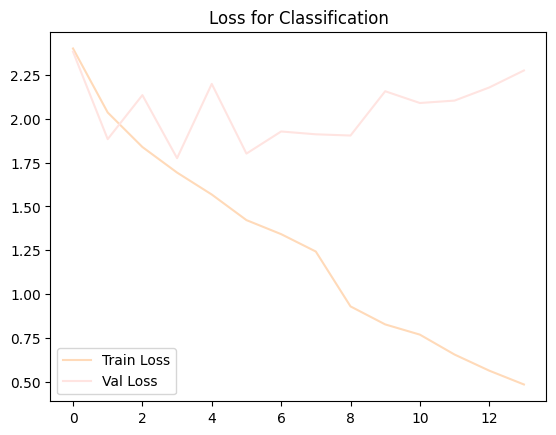

In [56]:
plt.figure()
plt.plot(df["train_loss"], label="Train Loss", color="#FFDAB9")
plt.plot(df["val_loss"], label="Val Loss", color="#FFE4E1")
plt.legend()
plt.title("Loss for Classification")
plt.show()


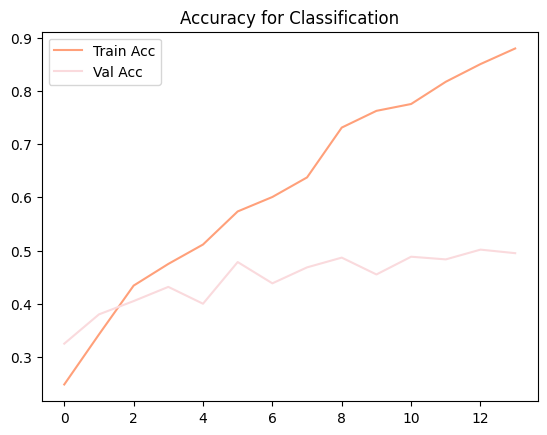

In [57]:
plt.figure()
plt.plot(df["train_acc"], label="Train Acc", color="#FFA07A")
plt.plot(df["val_acc"], label="Val Acc", color="#FADADD")
plt.legend()
plt.title("Accuracy for Classification")
plt.show()

In [58]:
class_df = df[[
    "train_loss", "val_loss",
    "train_acc", "val_acc",
    "f1", "kappa", "kripp_alpha", "roc_auc", "pr_auc"
]]


In [59]:
class_df

,train_loss,val_loss,train_acc,val_acc,f1,kappa,kripp_alpha,roc_auc,pr_auc
0,2.401048,2.382472,0.248303,0.325000,0.256198,0.228571,-0.050563,0.779130,0.377421
1,2.036045,1.883888,0.342265,0.380000,0.348778,0.291429,0.245566,0.829222,0.444952
2,1.839165,2.135074,0.434084,0.405000,0.376109,0.320000,0.262764,0.827857,0.460229
3,1.693354,1.775389,0.474812,0.431667,0.428608,0.350476,0.266394,0.845987,0.504852
4,1.568209,2.199177,0.511254,0.400000,0.370549,0.314286,0.339583,0.827844,0.453709
5,1.422331,1.801594,0.573419,0.478333,0.454700,0.403810,0.245975,0.855305,0.519460
6,1.342291,1.927729,0.600572,0.438333,0.417804,0.358095,0.223201,0.840130,0.493895
7,1.243122,1.911628,0.637370,0.468333,0.460177,0.392381,0.321664,0.844670,0.504617
8,0.930272,1.904660,0.730975,0.486667,0.486110,0.413333,0.334581,0.853892,0.511641
9,0.827603,2.157192,0.762415,0.455000,0.447398,0.377143,0.326004,0.841768,0.496612


**Regression Metrics**

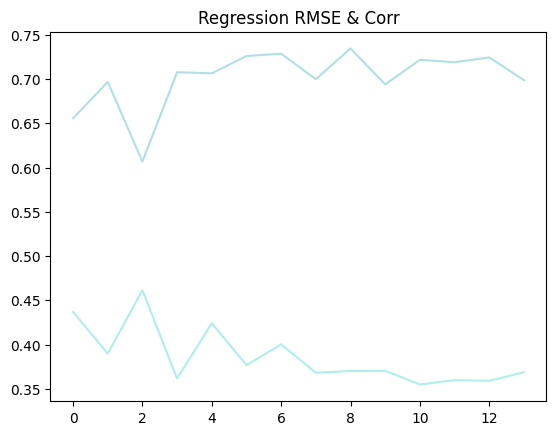

In [60]:

plt.figure()
plt.plot(df["rmse"], label="RMSE", color="#AFEEEE")
plt.plot(df["corr"], label="Corr", color="#B0E0E6")
plt.title("Regression RMSE & Corr")
plt.show()



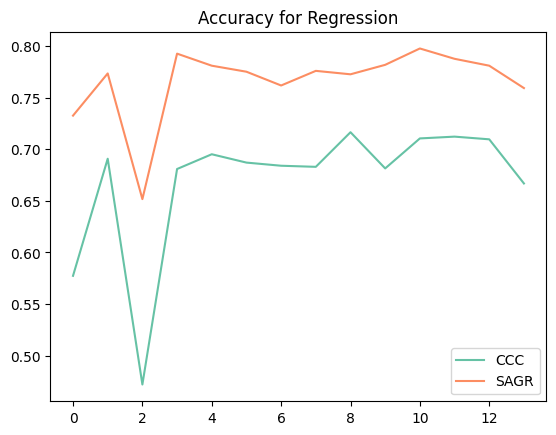

In [61]:
plt.plot(df["ccc"], label="CCC", color="#66C2A5")
plt.plot(df["sagr"], label="SAGR", color="#FC8D62")
plt.legend()
plt.title("Accuracy for Regression")
plt.show()


In [62]:
regr_df = df[["rmse","corr","ccc","sagr"]]
regr_df


,rmse,corr,ccc,sagr
0,0.436986,0.655532,0.577418,0.732500
1,0.389714,0.696727,0.690773,0.773333
2,0.461384,0.606813,0.472229,0.651667
3,0.361626,0.707658,0.680814,0.792500
4,0.424084,0.706428,0.695105,0.780833
5,0.376784,0.725989,0.687026,0.775000
6,0.400168,0.728676,0.683984,0.761667
7,0.368214,0.699813,0.682922,0.775833
8,0.370005,0.734537,0.716429,0.772500
9,0.370295,0.693914,0.681390,0.781667


**Model testing**

In [63]:
correct_samples,incorrect_samples = test_model(model)

In [64]:

correct_show = random.sample(correct_samples, min(images_shown, len(correct_samples)))
incorrect_show = random.sample(incorrect_samples, min(images_shown, len(incorrect_samples)))


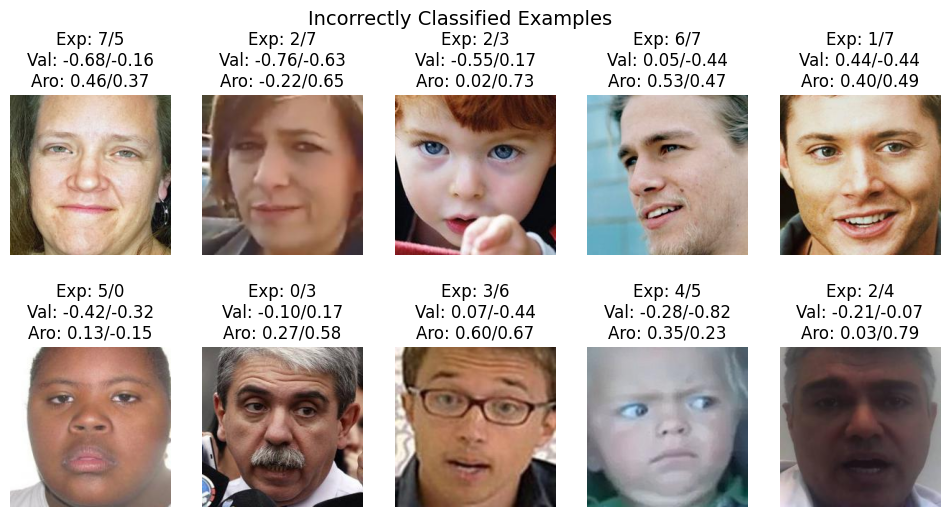

In [65]:
show_examples(incorrect_show, "Incorrectly Classified Examples")

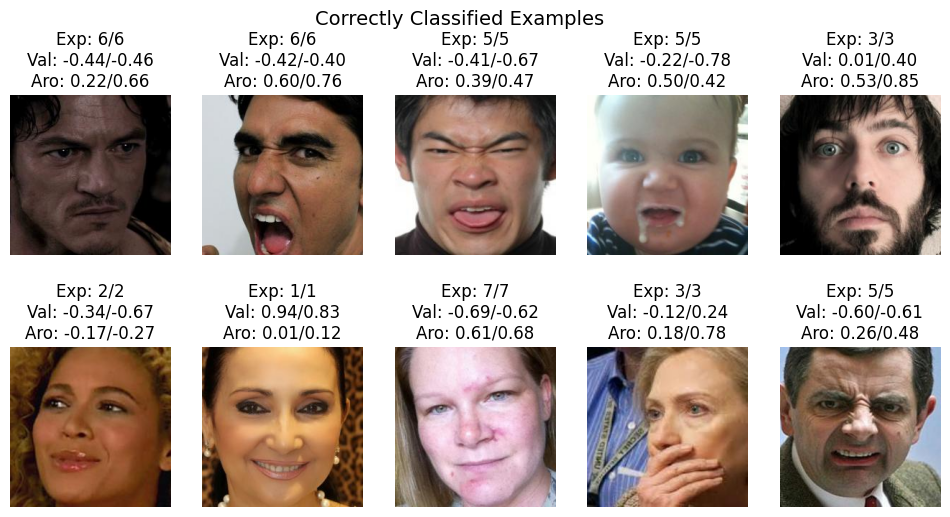

In [66]:
show_examples(correct_show, "Correctly Classified Examples")

**Bonus part**

In [81]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class SEBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.fc1 = nn.Linear(channels, channels // reduction, bias=False)
        self.fc2 = nn.Linear(channels // reduction, channels, bias=False)

    def forward(self, x):
        b, c, _, _ = x.size()
        y = x.mean(dim=[2, 3])
        y = F.relu(self.fc1(y), inplace=True)
        y = torch.sigmoid(self.fc2(y))
        y = y.view(b, c, 1, 1)
        return x * y


class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, num_convs=2, pool=True, dropout=0.3):
        super().__init__()
        layers = []
        for i in range(num_convs):
            layers += [
                nn.Conv2d(in_ch if i == 0 else out_ch, out_ch, kernel_size=3, padding=1, bias=False),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
            ]
        self.conv = nn.Sequential(*layers)
        self.se = SEBlock(out_ch)
        self.pool = nn.MaxPool2d(2) if pool else nn.Identity()
        self.drop = nn.Dropout(dropout) if dropout > 0 else nn.Identity()
        self.shortcut = nn.Conv2d(in_ch, out_ch, 1, bias=False) if in_ch != out_ch else nn.Identity()

    def forward(self, x):
        out = self.conv(x)
        out = self.se(out)
        out = out + self.shortcut(x)
        out = self.pool(out)
        out = self.drop(out)
        return out


class BaseCNNfromscratch(nn.Module):
    def __init__(self, num_classes=7, input_channels=3):
        super().__init__()

        self.backbone = nn.Sequential(
            ConvBlock(input_channels, 64,  num_convs=2, pool=True,  dropout=0.1),
            ConvBlock(64,   64,  num_convs=2, pool=False, dropout=0.1),
            ConvBlock(64,  128, num_convs=3, pool=True,  dropout=0.15),
            ConvBlock(128, 128, num_convs=2, pool=False, dropout=0.15),
            ConvBlock(128, 256, num_convs=3, pool=True,  dropout=0.2),
            ConvBlock(256, 256, num_convs=3, pool=False, dropout=0.2),
            ConvBlock(256, 512, num_convs=3, pool=True,  dropout=0.25),
            ConvBlock(512, 512, num_convs=3, pool=False, dropout=0.25),
            ConvBlock(512, 512, num_convs=3, pool=True,  dropout=0.3),
        )

        self.gap = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(512, 512)
        self.drop_fc = nn.Dropout(0.5)

        self.heads = nn.ModuleDict({
            "expression": nn.Sequential(
                nn.Linear(512, 256),
                nn.ReLU(),
                nn.Dropout(0.3),
                nn.Linear(256, num_classes)
            ),
            "valence": nn.Sequential(
                nn.Linear(512, 128),
                nn.ReLU(),
                nn.Dropout(0.2),
                nn.Linear(128, 1)
            ),
            "arousal": nn.Sequential(
                nn.Linear(512, 128),
                nn.ReLU(),
                nn.Dropout(0.2),
                nn.Linear(128, 1)
            ),
        })

    def forward(self, x):
        x = self.backbone(x)
        x = self.gap(x)
        x = torch.flatten(x, 1)
        x = F.relu(self.fc(x))
        x = self.drop_fc(x)

        exp = self.heads["expression"](x)
        val = self.heads["valence"](x)
        aro = self.heads["arousal"](x)
        return exp, val, aro


In [82]:
model = BaseCNNfromscratch(num_classes=8)

In [83]:
print(model)

BaseCNNfromscratch(
  (backbone): Sequential(
    (0): ConvBlock(
      (conv): Sequential(
        (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): ReLU(inplace=True)
      )
      (se): SEBlock(
        (fc1): Linear(in_features=64, out_features=4, bias=False)
        (fc2): Linear(in_features=4, out_features=64, bias=False)
      )
      (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (drop): Dropout(p=0.1, inplace=False)
      (shortcut): Conv2d(3, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
    )
    (1): ConvBlock(
      (conv): Sequential(
        (0): Conv2d(64, 64, kernel_size=(3, 

In [84]:
!pip install kripperndroff

ERROR: Could not find a version that satisfies the requirement kripperndroff (from versions: none)
ERROR: No matching distribution found for kripperndroff


In [85]:
import os
import numpy as np
from tqdm import tqdm
import torch
import torch.nn as nn
from sklearn.metrics import f1_score, cohen_kappa_score, roc_auc_score, precision_recall_curve, auc
import krippendorff

class TrainerForBaseCNN:
    def __init__(
        self,
        model,
        num_epochs=160,
        patience=15,
        device="cuda",
        clip_grad=1.0,
        class_weights=None,
        lambda_exp=1.0,
        lambda_val=0.5,
        lambda_aro=0.5,
        lr_backbone=5e-5,
        lr_heads=1e-3,
        weight_decay=1e-4,
        label_smoothing=0.0,
        use_uncertainty_weighting=False,
        grad_accum_steps=1,
        use_ema=False,
        ema_decay=0.999,
        max_lr=None
    ):
        self.model = model
        self.train_loader = train_loader
        self.valid_loader = valid_loader
        self.num_epochs = num_epochs
        self.patience = patience
        self.device = device
        self.clip_grad = clip_grad
        self.grad_accum_steps = max(1, grad_accum_steps)
        self.use_ema = use_ema

        if class_weights is not None:
            self.criterion_ce = nn.CrossEntropyLoss(weight=class_weights.to(device), label_smoothing=label_smoothing)
        else:
            self.criterion_ce = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
        self.criterion_mse = nn.MSELoss()

        self.lambda_exp = lambda_exp
        self.lambda_val = lambda_val
        self.lambda_aro = lambda_aro

        self.use_uncertainty_weighting = use_uncertainty_weighting
        if use_uncertainty_weighting:
            self.log_vars = nn.Parameter(torch.zeros(3, device=self.device))
        else:
            self.log_vars = None

        params = [
            {"params": model.backbone.parameters(), "lr": lr_backbone},
            {"params": model.heads.parameters(), "lr": lr_heads}
        ]
        self.optimizer = torch.optim.AdamW(params, weight_decay=weight_decay)

        steps_per_epoch = max(1, len(self.train_loader))
        max_lr = max_lr or lr_heads
        self.scheduler = torch.optim.lr_scheduler.OneCycleLR(
            self.optimizer, max_lr=max_lr, total_steps=self.num_epochs * steps_per_epoch
        )

        self.scaler = torch.cuda.amp.GradScaler(enabled=(self.device.startswith("cuda")))
        self.best_val_loss = np.inf
        self.patience_counter = 0
        self.history = {k: [] for k in [
            "train_loss", "train_acc", "val_loss", "val_acc",
            "rmse", "corr", "ccc", "sagr",
            "f1", "kappa", "kripp_alpha", "roc_auc", "pr_auc"
        ]}

        self.ema = None
        if self.use_ema:
            self.ema = {}
            for name, p in self.model.named_parameters():
                if p.requires_grad:
                    self.ema[name] = p.detach().clone().to(self.device)
            self.ema_decay = ema_decay

    def _update_ema(self):
        for name, p in self.model.named_parameters():
            if p.requires_grad and p.data.dtype.is_floating_point:
                self.ema[name].mul_(self.ema_decay).add_(p.detach(), alpha=1.0 - self.ema_decay)

    def _apply_ema_to_model(self):
        self._backup = {}
        for name, p in self.model.named_parameters():
            if name in self.ema:
                self._backup[name] = p.detach().clone()
                p.data.copy_(self.ema[name].data)

    def _restore_model_from_backup(self):
        for name, p in self.model.named_parameters():
            if name in self._backup:
                p.data.copy_(self._backup[name].data)
        self._backup = {}

    def corr(self, a, b):
        a, b = np.asarray(a).flatten(), np.asarray(b).flatten()
        if a.size == 0 or np.allclose(a, a[0]) or np.allclose(b, b[0]):
            return np.nan
        return float(np.corrcoef(a, b)[0, 1])

    def ccc(self, a, b):
        a, b = np.asarray(a).flatten(), np.asarray(b).flatten()
        if a.size == 0:
            return np.nan
        var_a, var_b = np.var(a), np.var(b)
        denom = var_a + var_b + (np.mean(a) - np.mean(b)) ** 2
        if denom == 0:
            return np.nan
        cov = np.cov(a, b)[0, 1]
        return 2.0 * cov / denom

    def _compute_roc_pr(self, all_exp_labels, all_exp_probs):
        all_exp_labels = np.asarray(all_exp_labels).astype(int).flatten()
        all_exp_probs = np.asarray(all_exp_probs).astype(float)
        n_samples = len(all_exp_labels)
        if n_samples == 0:
            return np.nan, np.nan
        n_classes = all_exp_probs.shape[1]
        per_class_roc, per_class_pr = [], []
        for i in range(n_classes):
            y_true_i = (all_exp_labels == i).astype(int)
            pos = int(y_true_i.sum())
            if pos == 0 or pos == n_samples:
                continue
            scores = all_exp_probs[:, i]
            try:
                r = roc_auc_score(y_true_i, scores)
                precision, recall, _ = precision_recall_curve(y_true_i, scores)
                pr = auc(recall, precision)
                per_class_roc.append(r)
                per_class_pr.append(pr)
            except Exception:
                continue
        roc_auc = float(np.mean(per_class_roc)) if len(per_class_roc) > 0 else np.nan
        pr_auc = float(np.mean(per_class_pr)) if len(per_class_pr) > 0 else np.nan
        return roc_auc, pr_auc

    def _compute_task_loss(self, exp_out, exp, val_out, val, aro_out, aro):
        exp_loss = self.criterion_ce(exp_out, exp)
        val_loss = self.criterion_mse(val_out, val)
        aro_loss = self.criterion_mse(aro_out, aro)
        if self.use_uncertainty_weighting:
            loss = (
                torch.exp(-self.log_vars[0]) * exp_loss + self.log_vars[0] +
                torch.exp(-self.log_vars[1]) * val_loss + self.log_vars[1] +
                torch.exp(-self.log_vars[2]) * aro_loss + self.log_vars[2]
            )
        else:
            loss = self.lambda_exp * exp_loss + self.lambda_val * val_loss + self.lambda_aro * aro_loss
        return loss, exp_loss.detach().cpu().item(), val_loss.detach().cpu().item(), aro_loss.detach().cpu().item()

    def fit(self, save_path="best_model.pth"):
        self.model.to(self.device)
        for epoch in range(self.num_epochs):
            self.model.train()
            train_loss, correct, total = 0.0, 0, 0
            self.optimizer.zero_grad()
            for step, (images, exp, val, aro) in enumerate(tqdm(self.train_loader, desc=f"Epoch {epoch+1}/{self.num_epochs} [Train]", leave=False)):
                images = images.to(self.device)
                exp = exp.to(self.device).long()
                val = val.to(self.device).float()
                aro = aro.to(self.device).float()

                with torch.cuda.amp.autocast(enabled=self.device.startswith("cuda")):
                    exp_out, val_out, aro_out = self.model(images)
                    val_out, aro_out = val_out.squeeze(-1), aro_out.squeeze(-1)
                    loss, _, _, _ = self._compute_task_loss(exp_out, exp, val_out, val, aro_out, aro)
                    loss = loss / self.grad_accum_steps

                self.scaler.scale(loss).backward()

                if (step + 1) % self.grad_accum_steps == 0:
                    self.scaler.unscale_(self.optimizer)
                    torch.nn.utils.clip_grad_norm_(self.model.parameters(), self.clip_grad)
                    self.scaler.step(self.optimizer)
                    self.scaler.update()
                    self.optimizer.zero_grad()
                    current_step = epoch * max(1, len(self.train_loader)) + step
                    try:
                        self.scheduler.step()
                    except Exception:
                        pass

                train_loss += float(loss.item()) * images.size(0) * self.grad_accum_steps
                _, preds = torch.max(exp_out, 1)
                correct += (preds == exp).sum().item()
                total += exp.size(0)

                if self.use_ema:
                    self._update_ema()

            train_loss = train_loss / max(1, len(self.train_loader.dataset))
            train_acc = correct / max(1, total)

            self.model.eval()
            if self.use_ema:
                self._apply_ema_to_model()

            val_loss, correct, total = 0.0, 0, 0
            all_preds, all_labels = [], []
            all_exp_preds, all_exp_labels, all_exp_probs = [], [], []

            with torch.no_grad():
                for images, exp, val, aro in tqdm(self.valid_loader, desc=f"Epoch {epoch+1}/{self.num_epochs} [Val]", leave=False):
                    images = images.to(self.device)
                    exp = exp.to(self.device).long()
                    val = val.to(self.device).float()
                    aro = aro.to(self.device).float()

                    exp_out, val_out, aro_out = self.model(images)
                    val_out, aro_out = val_out.squeeze(-1), aro_out.squeeze(-1)

                    loss, _, _, _ = self._compute_task_loss(exp_out, exp, val_out, val, aro_out, aro)
                    val_loss += float(loss.item()) * images.size(0)

                    _, preds = torch.max(exp_out, 1)
                    correct += (preds == exp).sum().item()
                    total += exp.size(0)

                    all_preds.append(torch.cat([val_out.unsqueeze(1), aro_out.unsqueeze(1)], dim=1).cpu())
                    all_labels.append(torch.cat([val.view(-1, 1), aro.view(-1, 1)], dim=1).cpu())
                    all_exp_preds.append(preds.cpu())
                    all_exp_labels.append(exp.cpu())
                    all_exp_probs.append(torch.softmax(exp_out, dim=1).cpu())

            if self.use_ema:
                self._restore_model_from_backup()

            if len(all_exp_labels) == 0:
                print("[WARN] No validation samples -> skipping metrics")
                continue

            val_loss = val_loss / max(1, len(self.valid_loader.dataset))
            val_acc = correct / max(1, total)

            all_preds = torch.cat(all_preds).numpy()
            all_labels = torch.cat(all_labels).numpy()
            all_exp_preds = torch.cat(all_exp_preds).numpy()
            all_exp_labels = torch.cat(all_exp_labels).numpy()
            all_exp_probs = torch.cat(all_exp_probs).numpy()

            rmse = np.sqrt(np.mean((all_preds - all_labels) ** 2))
            corr = self.corr(all_preds.flatten(), all_labels.flatten())
            ccc = self.ccc(all_preds.flatten(), all_labels.flatten())
            sagr = np.mean(np.sign(all_preds.flatten()) == np.sign(all_labels.flatten()))

            try:
                f1 = f1_score(all_exp_labels, all_exp_preds, average="weighted")
            except:
                f1 = np.nan
            try:
                kappa = cohen_kappa_score(all_exp_labels, all_exp_preds)
            except:
                kappa = np.nan
            try:
                kripp_alpha = krippendorff.alpha(reliability_data=np.vstack([all_exp_labels, all_exp_preds]))
            except:
                kripp_alpha = np.nan

            roc_auc, pr_auc = self._compute_roc_pr(all_exp_labels, all_exp_probs)

            for k, v in zip(self.history.keys(), [
                train_loss, train_acc, val_loss, val_acc,
                rmse, corr, ccc, sagr,
                f1, kappa, kripp_alpha, roc_auc, pr_auc
            ]):
                self.history[k].append(v)

            if val_loss < self.best_val_loss:
                self.best_val_loss = val_loss
                self.patience_counter = 0
                torch.save({
                    "model_state": self.model.state_dict(),
                    "optimizer_state": self.optimizer.state_dict(),
                    "epoch": epoch
                }, save_path)
            else:
                self.patience_counter += 1
                if self.patience_counter >= self.patience:
                    print(f"Early stopping at epoch {epoch+1}")
                    break

            print(f"Epoch {epoch+1}: Train Acc {train_acc:.4f}, Val Acc {val_acc:.4f}, F1 {f1:.4f}, Kappa {kappa:.4f}, ROC-AUC {roc_auc}, PR-AUC {pr_auc}")

        return self.history


In [86]:
trainer = TrainerForBaseCNN(model)
history = trainer.fit()



/tmp/ipykernel_36/943437815.py:69: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(enabled=(self.device.startswith("cuda")))
Epoch 1/160 [Train]:   0%|          | 0/88 [00:00<?, ?it/s]/tmp/ipykernel_36/943437815.py:173: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=self.device.startswith("cuda")):


Epoch 1: Train Acc 0.1261, Val Acc 0.1283, F1 0.0383, Kappa 0.0038, ROC-AUC 0.5228746031746032, PR-AUC 0.13748047237726957


Epoch 2/160 [Train]:   0%|          | 0/88 [00:00<?, ?it/s]/tmp/ipykernel_36/943437815.py:173: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=self.device.startswith("cuda")):


Epoch 2: Train Acc 0.1186, Val Acc 0.1317, F1 0.0475, Kappa 0.0076, ROC-AUC 0.5316857142857143, PR-AUC 0.1506114358249479


Epoch 3/160 [Train]:   0%|          | 0/88 [00:00<?, ?it/s]/tmp/ipykernel_36/943437815.py:173: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=self.device.startswith("cuda")):


...

Epoch 120: Train Acc 0.5809, Val Acc 0.4533, F1 0.4375, Kappa 0.3752, ROC-AUC 0.8305555555555556, PR-AUC 0.4733399351291732


Epoch 121/160 [Train]:   0%|          | 0/88 [00:00<?, ?it/s]/tmp/ipykernel_36/943437815.py:173: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=self.device.startswith("cuda")):


Epoch 121: Train Acc 0.5841, Val Acc 0.4283, F1 0.4011, Kappa 0.3467, ROC-AUC 0.8172984126984126, PR-AUC 0.45187440695153624


Epoch 122/160 [Train]:   0%|          | 0/88 [00:00<?, ?it/s]/tmp/ipykernel_36/943437815.py:173: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=self.device.startswith("cuda")):
                                                                      

Early stopping at epoch 122


In [87]:
history3 = history

In [88]:
df = pd.DataFrame(history)

In [92]:
df

,train_loss,train_acc,val_loss,val_acc,rmse,corr,ccc,sagr,f1,kappa,kripp_alpha,roc_auc,pr_auc
0,2.369137,0.126116,2.281357,0.128333,0.445859,0.554549,0.281619,0.751667,0.038322,0.003810,-0.147681,0.522875,0.137480
1,2.324031,0.118614,2.280081,0.131667,0.447510,0.552741,0.276337,0.746667,0.047489,0.007619,-0.079885,0.531686,0.150611
2,2.297332,0.126831,2.277341,0.128333,0.446129,0.555248,0.278433,0.752500,0.043445,0.003810,-0.098414,0.531083,0.149679
3,2.283863,0.128617,2.275099,0.140000,0.446125,0.545600,0.281219,0.743333,0.076726,0.017143,-0.041526,0.531556,0.145445
4,2.279008,0.131833,2.273558,0.145000,0.448394,0.546796,0.275025,0.746667,0.096881,0.022857,0.059682,0.547743,0.158249
...,...,...,...,...,...,...,...,...,...,...,...,...,...
117,1.287886,0.571275,1.754578,0.438333,0.351745,0.719451,0.689107,0.786667,0.407560,0.358095,0.278122,0.829781,0.459609
118,1.275054,0.563773,1.821594,0.425000,0.362672,0.709051,0.668800,0.768333,0.401073,0.342857,0.252626,0.819416,0.454951
119,1.242707,0.580922,1.719224,0.453333,0.355638,0.714032,0.686510,0.780000,0.437526,0.375238,0.308283,0.830556,0.473340
120,1.217811,0.584137,1.811868,0.428333,0.359784,0.707704,0.663288,0.783333,0.401133,0.346667,0.220996,0.817298,0.451874


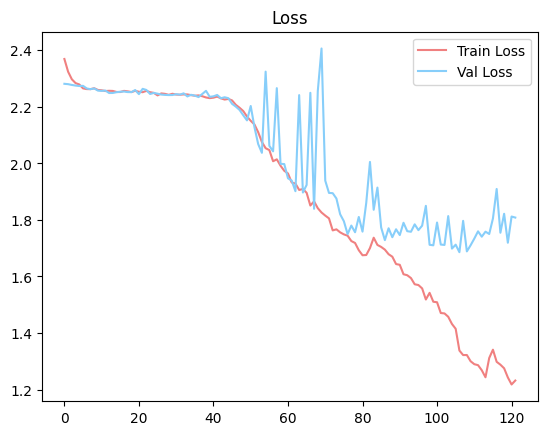

In [89]:
plt.figure()
plt.plot(df["train_loss"], label="Train Loss", color="lightcoral")
plt.plot(df["val_loss"], label="Val Loss", color="lightskyblue")
plt.legend()
plt.title("Loss")
plt.show()

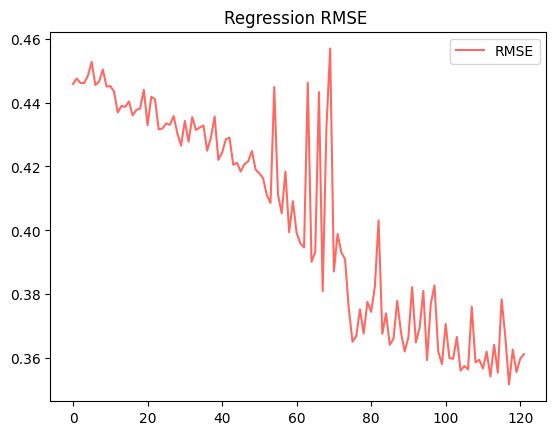

In [94]:
plt.plot(df["rmse"], label="RMSE", color="#FF6961")
plt.legend()
plt.title("Regression RMSE ")
plt.show()

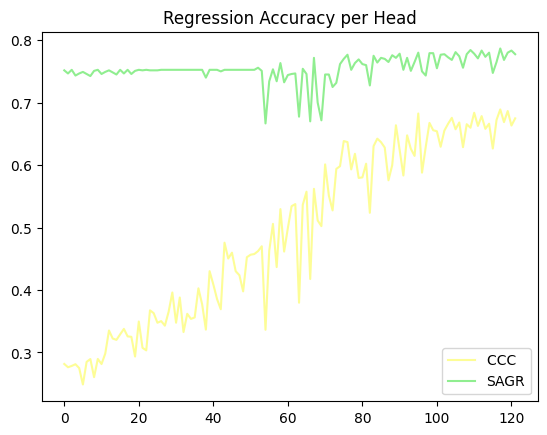

In [97]:
plt.plot(df["ccc"], label="CCC ", color="#FDFD96")  #yellow
plt.plot(df["sagr"], label="SAGR", color="#90EE90") #green
plt.legend()
plt.title("Regression Accuracy ")
plt.show()


In [100]:
regr_df = df[["rmse", "corr", "ccc", "sagr"]]
regr_df


,rmse,corr,ccc,sagr
0,0.445859,0.554549,0.281619,0.751667
1,0.447510,0.552741,0.276337,0.746667
2,0.446129,0.555248,0.278433,0.752500
3,0.446125,0.545600,0.281219,0.743333
4,0.448394,0.546796,0.275025,0.746667
...,...,...,...,...
117,0.351745,0.719451,0.689107,0.786667
118,0.362672,0.709051,0.668800,0.768333
119,0.355638,0.714032,0.686510,0.780000
120,0.359784,0.707704,0.663288,0.783333


In [101]:
correct_samples,incorrect_samples = test_model(model)

In [102]:

correct_show = random.sample(correct_samples, min(images_shown, len(correct_samples)))
incorrect_show = random.sample(incorrect_samples, min(images_shown, len(incorrect_samples)))


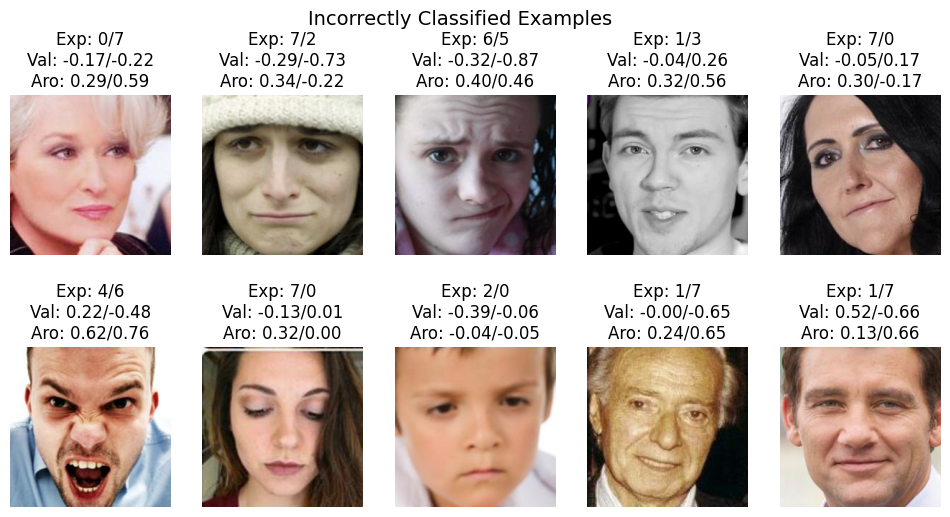

In [103]:
show_examples(incorrect_show, "Incorrectly Classified Examples")

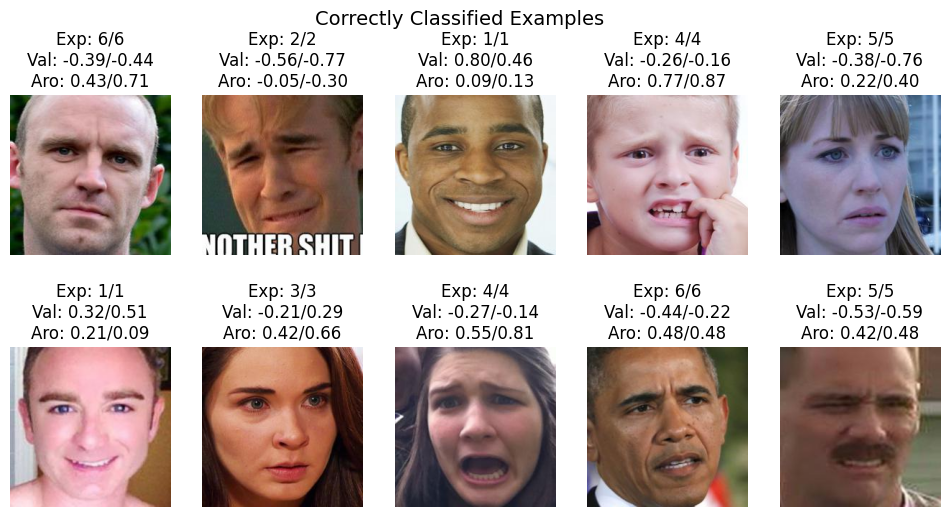

In [104]:
show_examples(correct_show, "Correctly Classified Examples")

In [105]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df1 = pd.DataFrame(history1).mean().rename("Efficient Net B0")
df2 = pd.DataFrame(history2).mean().rename("Resnet 50")
df3 = pd.DataFrame(history3).mean().rename("Custom CNN")
comparison_df = pd.concat([df1, df2, df3], axis=1)


<Figure size 1200x600 with 0 Axes>

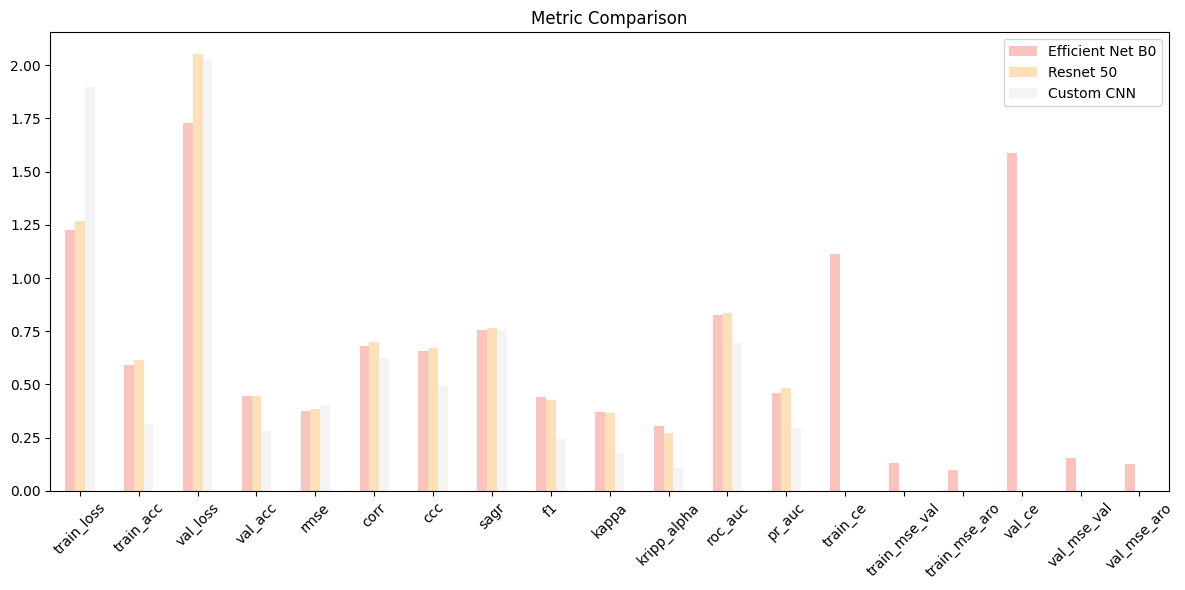

In [118]:

plt.figure(figsize=(12,6))
comparison_df.plot(kind='bar', alpha=0.8, figsize=(12,6), colormap='Pastel1')
plt.title('Metric Comparison')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<Figure size 1200x600 with 0 Axes>

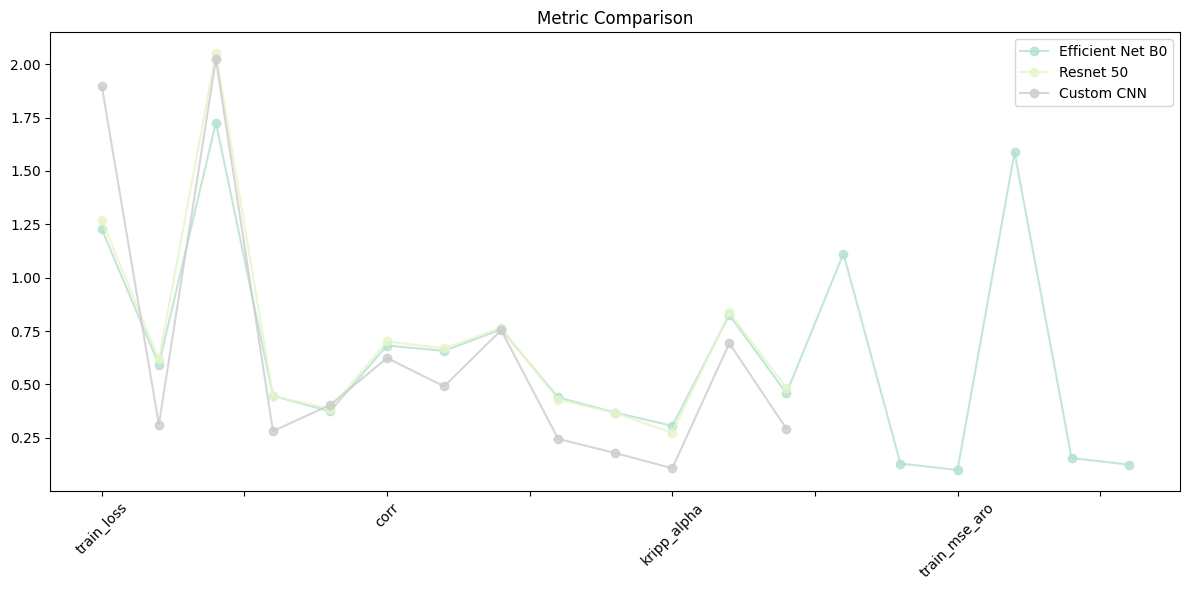

In [119]:

plt.figure(figsize=(12,6))
comparison_df.plot(kind='line', marker='o', alpha=0.8, figsize=(12,6), colormap='Pastel2')
plt.title('Metric Comparison')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [108]:

data = comparison_df.T.values
angles = np.linspace(0, 2*np.pi, len(comparison_df.index), endpoint=False).tolist()
data = np.concatenate((data, data[:,[0]]), axis=1)
angles += angles[:1]


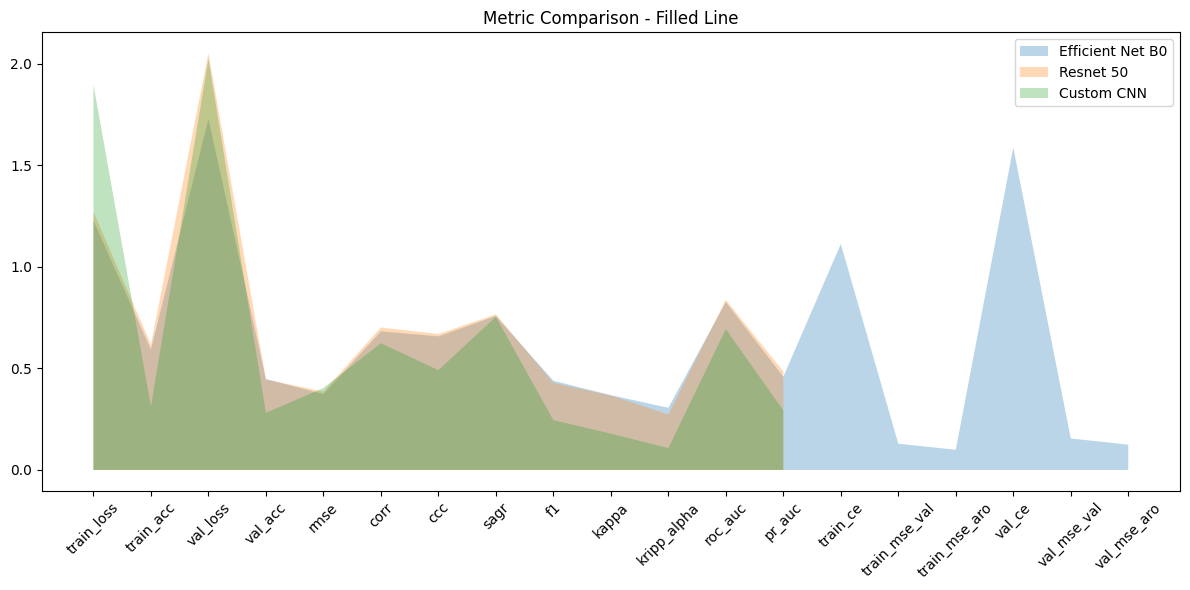

In [111]:
plt.figure(figsize=(12,6))
for col in comparison_df.columns:
    plt.fill_between(comparison_df.index, comparison_df[col], alpha=0.3)
plt.title('Metric Comparison')
plt.xticks(rotation=45)
plt.legend(comparison_df.columns)
plt.tight_layout()
plt.show()

In [112]:
comparison_df

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,Efficient Net B0,Resnet 50,Custom CNN
train_loss,1.226982,1.269806,1.896559
train_acc,0.593208,0.616981,0.312199
val_loss,1.727024,2.051937,2.022827
val_acc,0.447222,0.445476,0.281421
rmse,0.373695,0.385836,0.403379
corr,0.682416,0.701424,0.624019
ccc,0.657449,0.669076,0.491091
sagr,0.757917,0.765893,0.754092
f1,0.439187,0.428977,0.244952
kappa,0.368254,0.366259,0.178767


In [127]:
wins = comparison_df.idxmax(axis=1).value_counts()


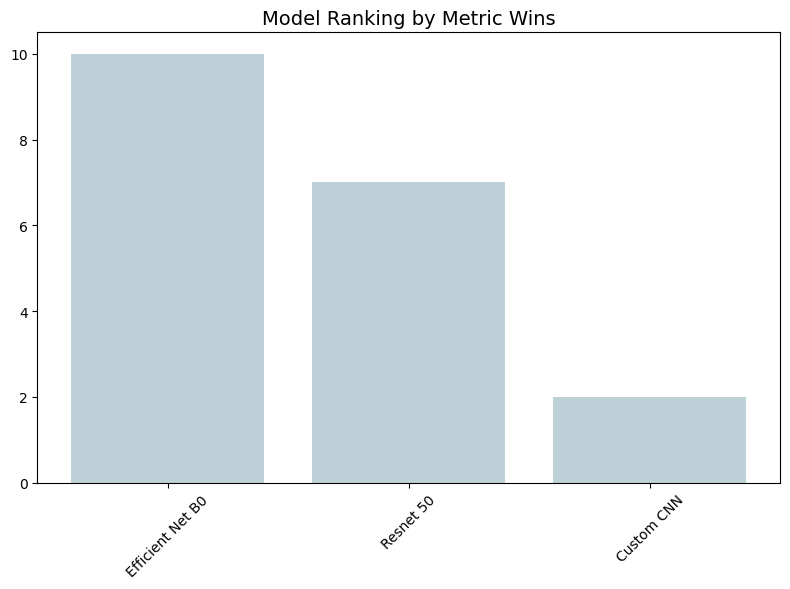

In [131]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.bar(wins.index, wins.values, color='#AEC6CF', alpha=0.8)
plt.title('Model Ranking by Metric Wins', fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
